In [1]:
import torch
from torch.distributions import Normal

import sys
sys.path.append('drnpe')

import lightning

from hydra import compose, initialize
from hydra.utils import instantiate

import matplotlib.pyplot as plt

We load the config and instantiate the data module:

In [2]:
with initialize(version_base=None, config_path="drnpe/conf"):
    cfg = compose(config_name="config")

lightning.seed_everything(cfg.seed)

datamodule = instantiate(cfg.datamodule)

Seed set to 42


We also load in two encoders, one trained with the standard NPE objective (i.e., KL ball in DRNPE objective has $\delta=0$) and one trained with the DRNPE objective with $\delta > 0$:

In [3]:
encoder_npe = instantiate(cfg.encoder)

state_dict = torch.load("trained_ckpts/network_npe.ckpt")['state_dict']
encoder_npe.load_state_dict(state_dict)
encoder_npe.eval()

Encoder(
  (net): LocationScaleNet(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)

In [4]:
encoder_drnpe = instantiate(cfg.encoder)

state_dict = torch.load("trained_ckpts/network_drnpe.ckpt")['state_dict']
encoder_drnpe.load_state_dict(state_dict)
encoder_drnpe.eval()

Encoder(
  (net): LocationScaleNet(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)

We define a function to plot the nominal versus empirical coverage probabilities of credible intervals computed using a trained `encoder`. This function generates a new batch of `num_test_samples` $(z,x)$ pairs. If `likelihood_stdev_multiplier = 1.0`, these pairs are generated from the same generative model used during training. If this multiplier does not equal 1.0, the model used for evaluation is misspecified.

In [5]:
def plot_coverage_probabilities(num_test_samples, encoder, likelihood_stdev_multiplier):
    num_subplots = len(likelihood_stdev_multiplier)
    fig, ax = plt.subplots(1, num_subplots, figsize = (4 * num_subplots, 4))
    if num_subplots == 1:
        ax = [ax]
    
    for j in range(num_subplots):
        z_correct = Normal(0.0, datamodule.prior_stdev).sample([num_test_samples])
        x_correct = Normal(z_correct, likelihood_stdev_multiplier[j] * datamodule.likelihood_stdev).sample([datamodule.num_observations]).permute(1,0)

        mu, logsigma = encoder.net(x_correct)
        sigma = torch.exp(logsigma)

        confidence_levels = torch.linspace(0.05, 0.95, steps = 19)
        quantiles = Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2)

        lower = (mu.unsqueeze(-1) - quantiles * sigma.unsqueeze(-1)).detach().cpu()
        upper = (mu.unsqueeze(-1) + quantiles * sigma.unsqueeze(-1)).detach().cpu()

        coverage_probs = ((z_correct.cpu().unsqueeze(-1) >= lower) * (z_correct.cpu().unsqueeze(-1) <= upper)).float().mean(0)
        
        _ = ax[j].scatter(confidence_levels.cpu(), coverage_probs.cpu())
        _ = ax[j].axline((0,0), slope = 1, color = 'black')
        _ = ax[j].set_xlim(0, 1)
        _ = ax[j].set_ylim(0, 1)
        _ = ax[j].set_title(f'$\\sigma$ multiplier = {likelihood_stdev_multiplier[j]}')
        _ = ax[j].set_xlabel('Nominal coverage probability')
        _ = ax[j].set_ylabel('Empirical coverage probability')
    
    _ = fig.tight_layout()

**Scenario 1A:** Train with standard NPE objective (KL ball has $\delta = 0$), evaluate on correctly specified model:

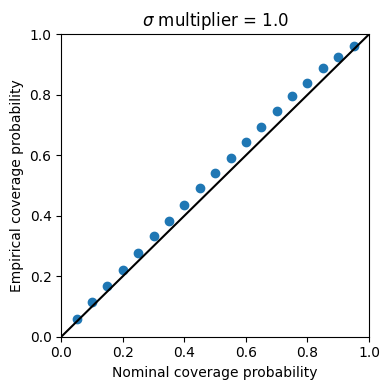

In [6]:
plot_coverage_probabilities(10000, encoder_npe, [1.0])

**Scenario 1B:** Train with standard NPE objective (KL ball has $\delta = 0$), evaluate on misspecified model:

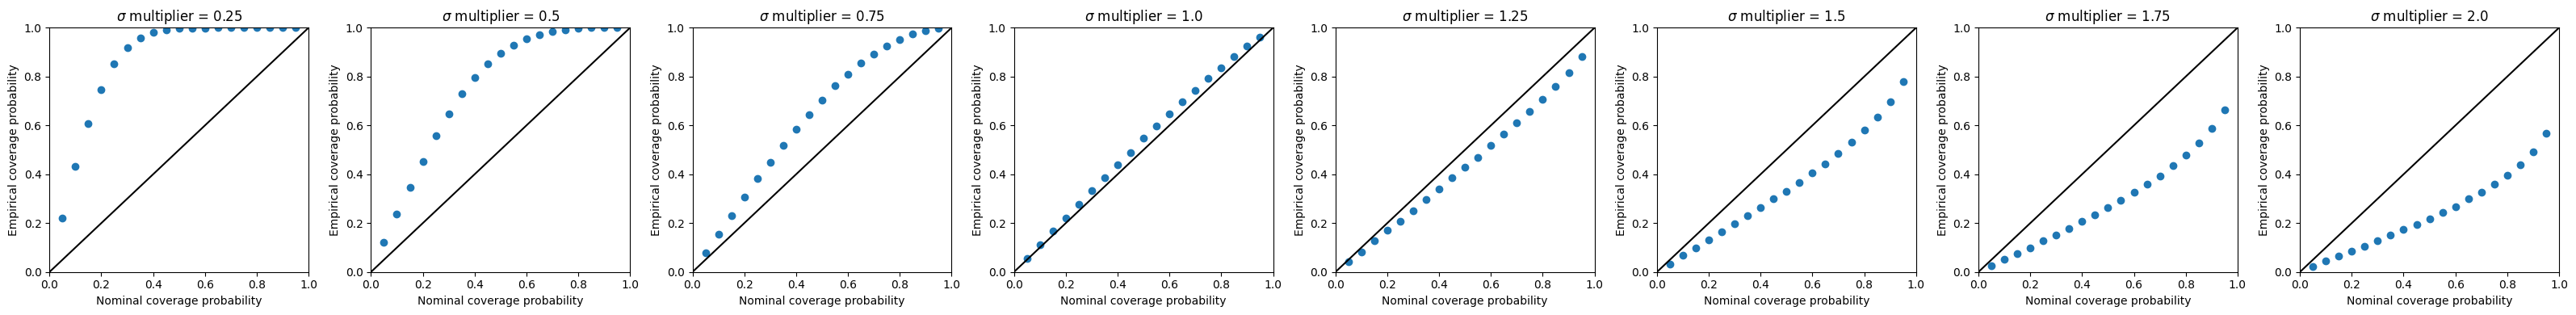

In [7]:
plot_coverage_probabilities(10000, encoder_npe, [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])

**Scenario 2A:** Train with DRNPE objective (KL ball has $\delta > 0$), evaluate on correctly specified model:

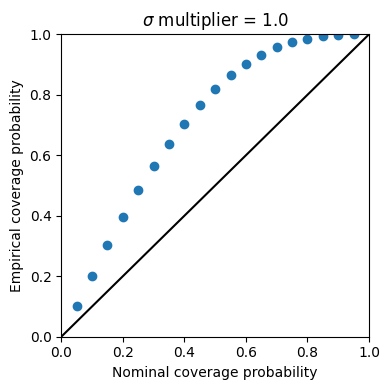

In [8]:
plot_coverage_probabilities(10000, encoder_drnpe, [1.0])

**Scenario 2B:** Train with DRNPE objective (KL ball has $\delta > 0$), evaluate on misspecified model:

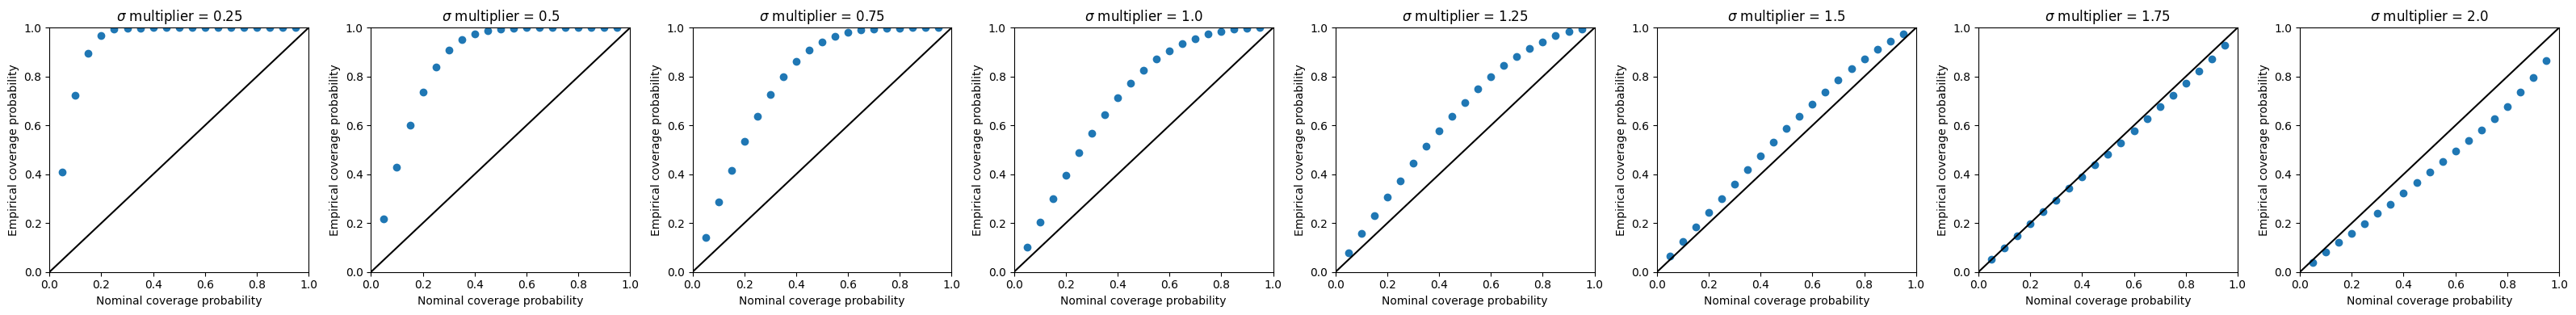

In [9]:
plot_coverage_probabilities(10000, encoder_drnpe, [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])